In [1]:
import sys
sys.path.append('/Users/anyaphillips/Desktop/harvard/research/via_binaries/scripts')

import functions as paf
import petar
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('vedant')
%matplotlib inline
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm


from tqdm import tqdm

import pandas as pd

from astropy.table import Table
import astropy.constants as const
import astropy.units as u
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpecFromSubplotSpec

import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

import viamock

lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

Duplicate key in file PosixPath('/Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle'), line 46 ('lines.linewidth : 3')

Bad key hist.type in file /Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle, line 45 ('hist.type : step')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.8/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution
/opt/anaconda3/envs/viamock/lib/python3.10/site-packages/matplotlib_inline/config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


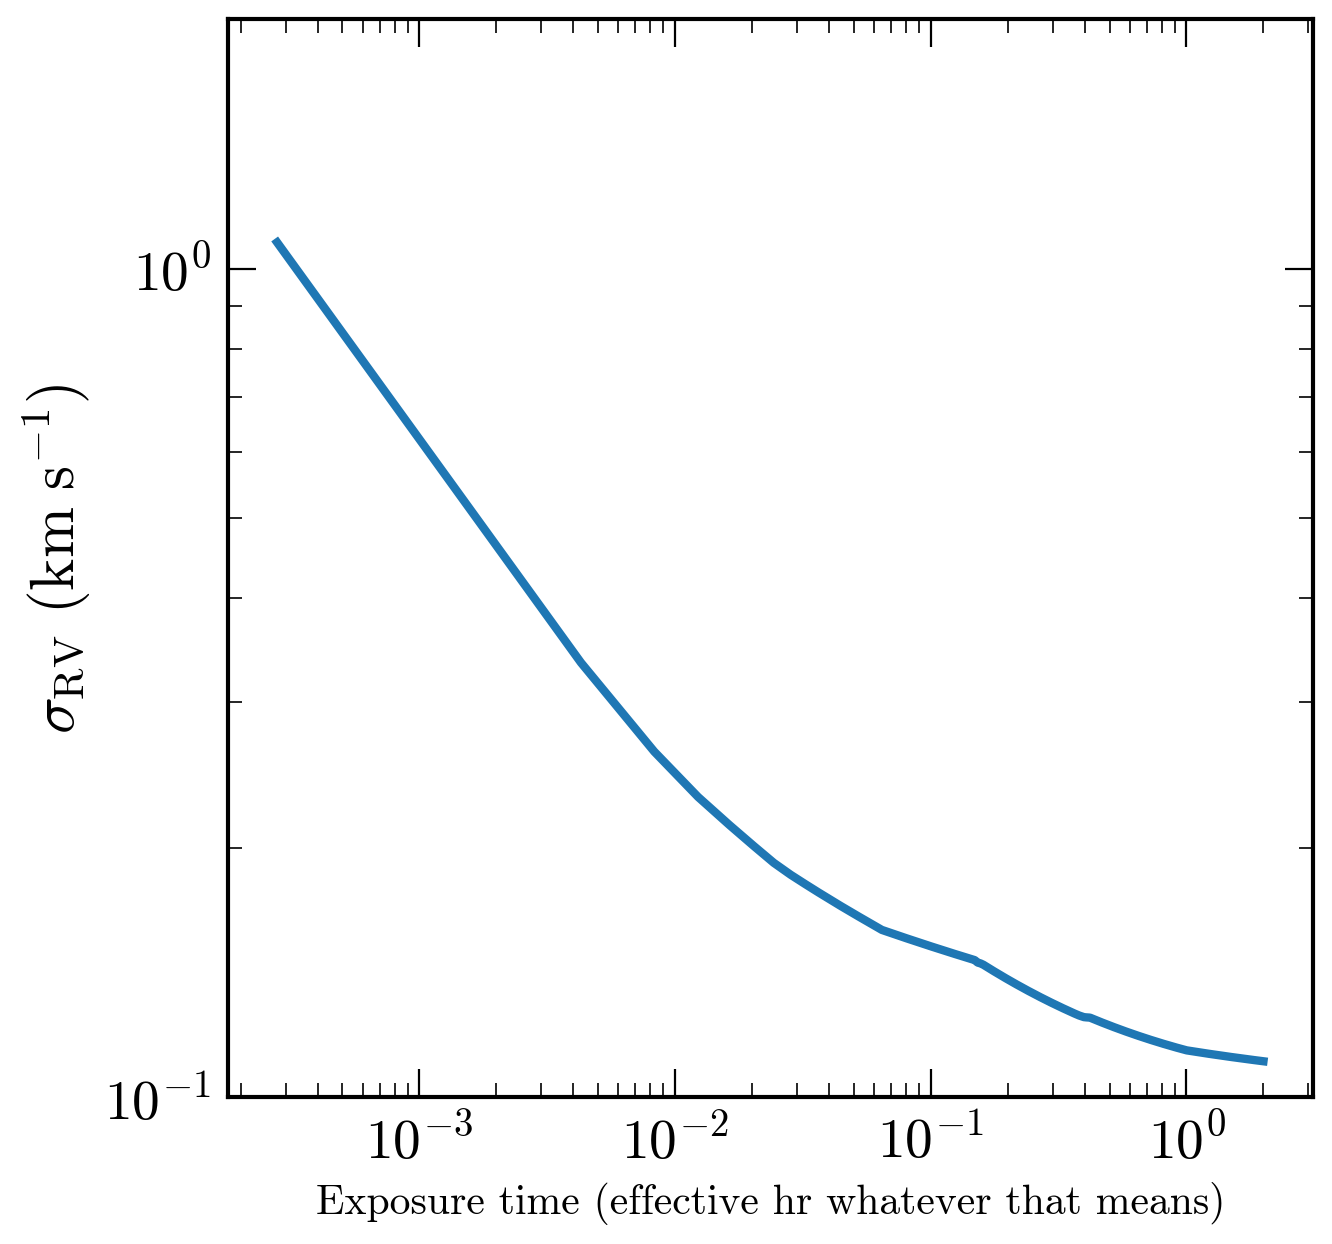

In [144]:
# test run with viamock

### deciding that each stream star gets 2 ehrs 
exptimes = np.linspace(1*u.s.to(u.hr), 2, 500)
ervs = []
for ehr in exptimes:
    erv = viamock.errors.get_viaspec_errors(G=17, feh=-2.0, logteff = np.log10(4700), exptime_ehr=ehr)
    ervs.append(erv[0])

ervs = np.array(ervs)

fig, ax = plt.subplots()
ax.plot(exptimes, ervs)
ax.set_xlabel('Exposure time (effective hr whatever that means)', fontsize=15)
ax.set_ylabel(r'$\sigma_{\rm RV}~(\rm km~s^{-1})$')
ax.set_yscale("log")
ax.set_ylim(0.1, 2)
ax.set_xscale("log")

In [3]:
### load binaries: 

binaries = pd.read_csv('detection_fractions_dense/cosmic_example_IBC.csv')
N = len(binaries)
print(N)

15000


In [4]:
# do nominal mock observations
### stack orbital params. want v0 (km/s), K (km/s), w, phi0, e, P (day)
rng = np.random.default_rng(seed=42)

m1 = binaries['mass_1'].values * u.Msun
m2 = binaries['mass_2'].values * u.Msun
mtot = m1+m2
P = binaries['porb'].values * u.day # days
a = paf.calc_a(P, mtot)

e = binaries['ecc'].values
i = paf.draw_inclinations(N, rng=rng)
K = paf.calc_K(mtot, m2, a, e, P, i)
v0 = np.zeros(N)*(u.km/u.s)

w = rng.uniform(low=0, high=2*np.pi, size=N)
phi0 = rng.uniform(low=0, high=1, size=N)

params = np.array([
    v0.to(u.km/u.s).value,
    K.to(u.km/u.s).value, 
    w,
    phi0,
    e,
    P.to(u.day).value
]).T

# results from `detection_fractions_sparse`

In [105]:
# institutional knowledge of what I ran in the slurm array. 
dt1_min, dt1_max, dt1_step = 2,150,2
dt1_vals  = np.arange(dt1_min, dt1_max+dt1_step, dt1_step) 

dt2_min, dt2_max, dt2_step = 30, 10*365, 10
dt2_vals = np.arange(dt2_min, dt2_max+dt2_step, dt2_step)

dfa = []

for k, dt1 in enumerate(dt1_vals):
    dfa_this_dt1 = np.loadtxt("detection_fractions_sparse/ms_%i.txt"%k)
    dfa.append(dfa_this_dt1)
dfa = np.array(dfa)
len(dt2_vals)

363

/var/folders/q2/m18s57611677cjnvtmvry2v80000gn/T/ipykernel_94445/2213302134.py:35: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ob = ax.contour(X,Y,Z, levels=np.arange(0.36, 0.60, 0.01),


<a list of 22 text.Text objects>

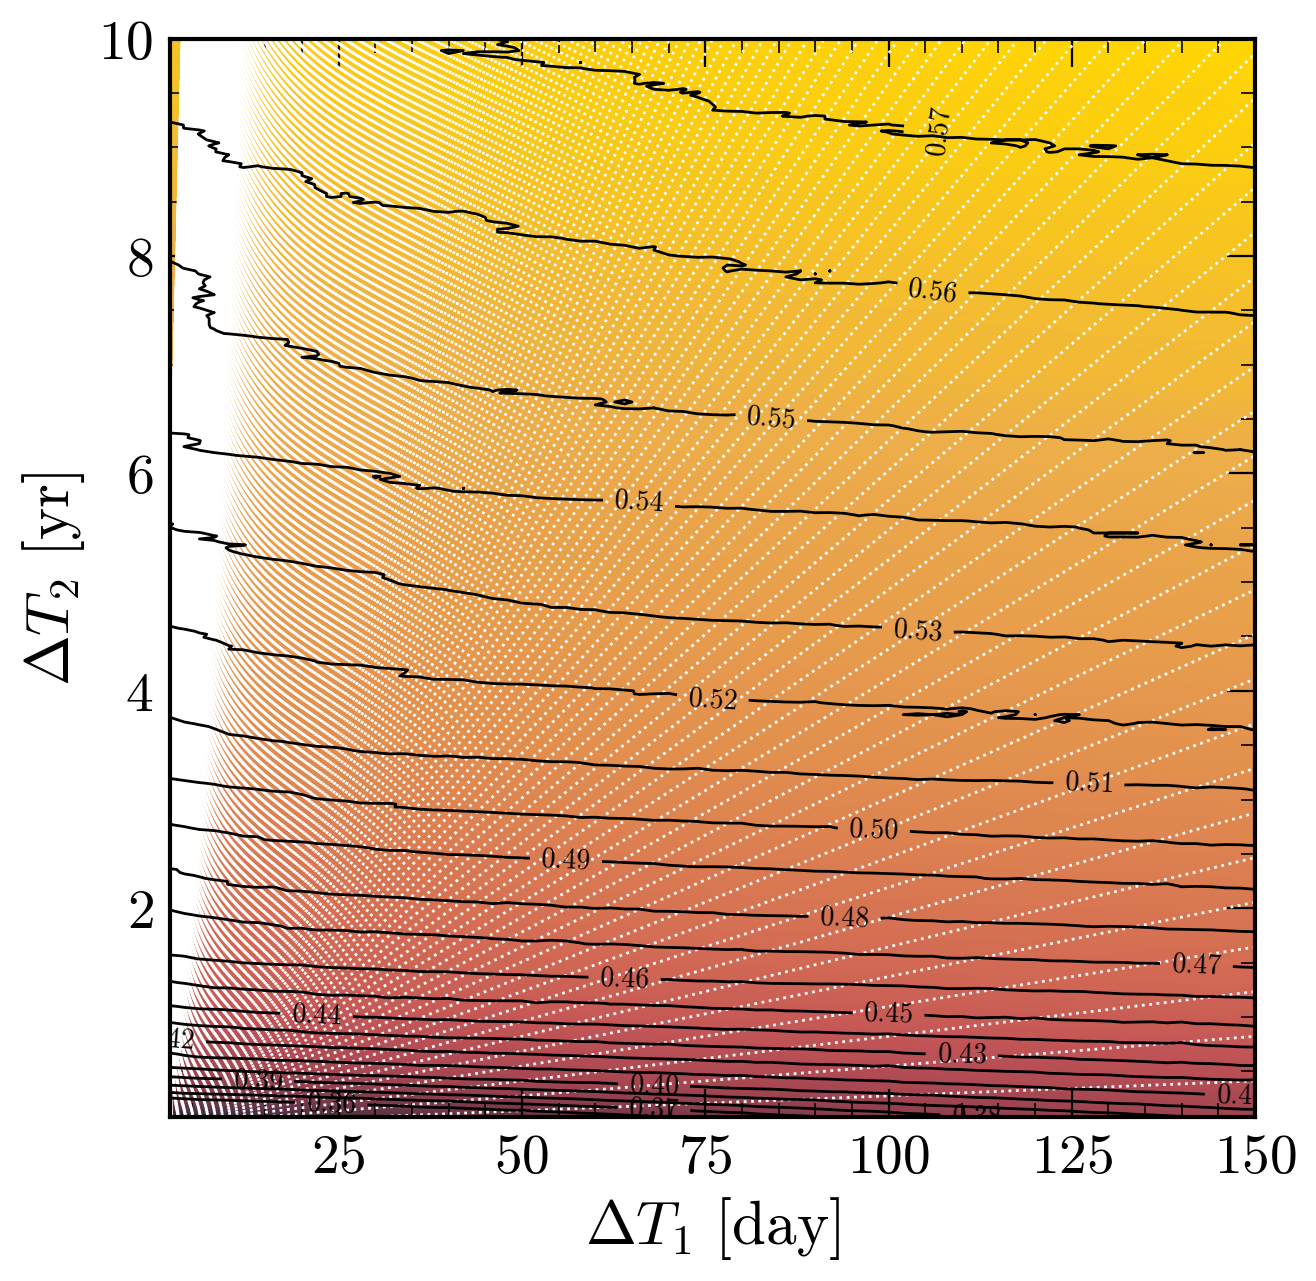

In [108]:
colors=["#212738","#4D3041","#79394A","#994250","#B24B54","#C55756","#D26A54","#DC8051","#E5974D","#EDAE49", "gold"]
# colors.reverse()
# colors = paf.define_simcolors()
df_cmap = LinearSegmentedColormap.from_list('df_cmap', colors)#[1]+colors[0])

X, Y = np.meshgrid(dt1_vals, dt2_vals)
Z = dfa.T

Y = Y/365
fig, ax = plt.subplots()
# ax.imshow(dfa, cmap=time_cmap)
ob = ax.contourf(X,Y, Z, cmap=df_cmap, levels=1000)
divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# cax.set_yticklabels(np.arange(0.44, 0.53, 0.01))
# fig.colorbar(ob, cax=cax, label=r"detection fraction")


### add lines where dt2 is an integer multiple of dt1
x = np.linspace(np.min(dt1_vals), np.max(dt1_vals), 100)
n_vals = np.arange(1, 1000, 1)
for n in n_vals:
    y = n*x
    y = y/365
    ax.plot(x,y, c='white', lw=1, ls=':')



ax.set_ylim(np.min(Y), np.max(Y))
ax.set_xlabel(r"$\Delta T_1~\rm [day]$")
ax.set_ylabel(r'$\Delta T_2~\rm [yr]$')
# ax.set_xscale('log')
# ax.set_yscale('log')

ob = ax.contour(X,Y,Z, levels=np.arange(0.36, 0.60, 0.01),
           linestyle="solid", colors="k", linewidths=1)
ax.clabel(ob, ob.levels, fontsize=10)

# results from `detection_fractions_dense`

In [109]:
### eventually, do Delta t_1 in 1-day increments, 
# delta t2 from like 1--360 days also in 1-day increments. 
# this will be the check on whether period aliasing is a problem or not


# institutional knowledge of what I ran in the slurm array. 
dt1_min, dt1_max, dt1_step = 1,150,1
dt1_vals  = np.arange(dt1_min, dt1_max+dt1_step, dt1_step) 

dt2_min, dt2_max, dt2_step = 1, 2*365, 1
dt2_vals = np.arange(dt2_min, dt2_max+dt2_step, dt2_step)

dfa = []

for k, dt1 in enumerate(dt1_vals, start=1):
    dfa_this_dt1 = np.loadtxt("detection_fractions_dense/ms_%i.txt"%k)
    dfa.append(dfa_this_dt1)
dfa = np.array(dfa)

/var/folders/q2/m18s57611677cjnvtmvry2v80000gn/T/ipykernel_94445/1771318247.py:25: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ob2 = ax.contour(X,Y,Z, levels=black_levels,


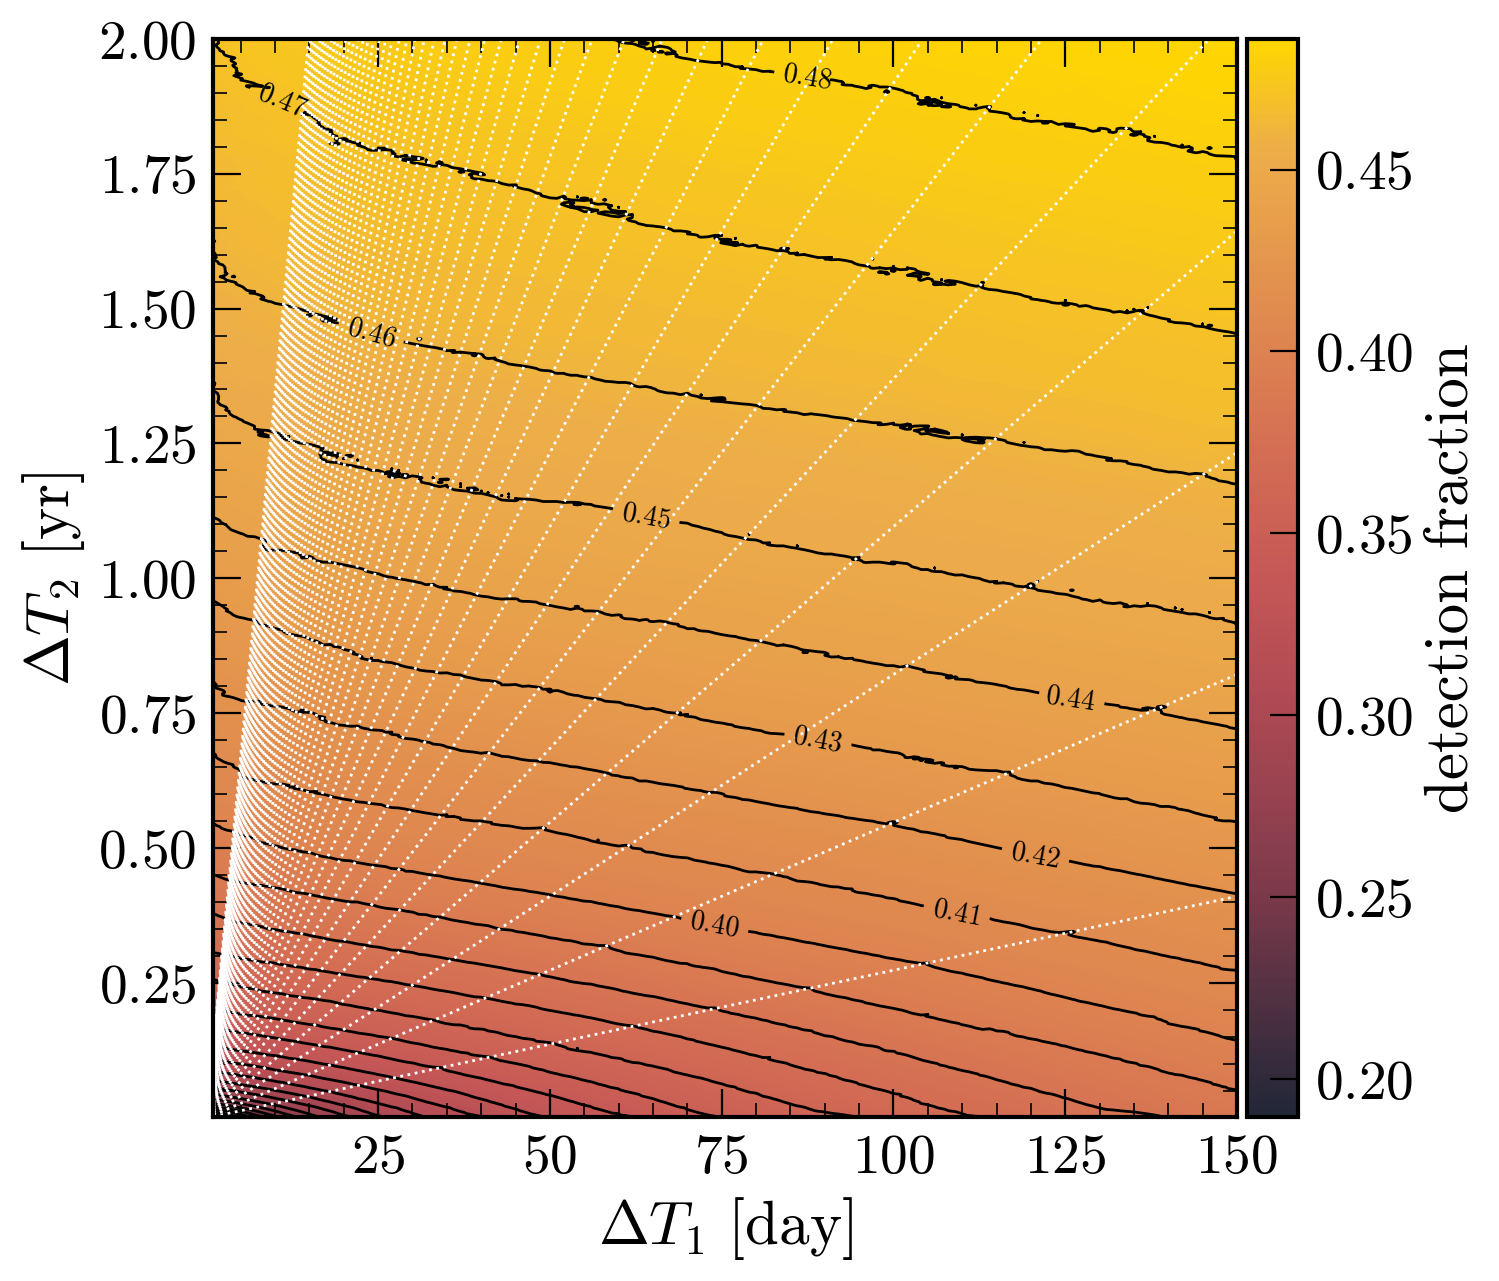

In [110]:
colors=["#212738","#4D3041","#79394A","#994250","#B24B54","#C55756","#D26A54","#DC8051","#E5974D","#EDAE49", "gold"]
# colors.reverse()
# colors = paf.define_simcolors()
df_cmap = LinearSegmentedColormap.from_list('df_cmap', colors)#[1]+colors[0])

X, Y = np.meshgrid(dt1_vals, dt2_vals)
Z = dfa.T

Y = Y/365
fig, ax = plt.subplots()
# ax.imshow(dfa, cmap=time_cmap)
ob = ax.contourf(X,Y, Z, cmap=df_cmap, levels=1000)


ax.set_ylim(np.min(Y), np.max(Y))
ax.set_xlim(np.min(X), np.max(X))
ax.set_xlabel(r"$\Delta T_1~\rm [day]$")
ax.set_ylabel(r'$\Delta T_2~\rm [yr]$')
# ax.set_xscale('log')
# ax.set_yscale('log')


# black_levels = np.arange(0.2, 0.5, 0.002) ### <-- dense black contours to look more at aliasing
black_levels = np.arange(0.2, 0.5, 0.01)
ob2 = ax.contour(X,Y,Z, levels=black_levels,
           linestyle="solid", colors="k", linewidths=1)
ax.clabel(ob2, ob2.levels[20:],
           fontsize=10)


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(ob, cax=cax, label=r"detection fraction")
cbar.set_ticks(black_levels[::5])

### add lines where dt2 is an integer multiple of dt1
x = np.linspace(np.min(dt1_vals), np.max(dt1_vals), 2)
n_vals = np.arange(1, 50, 1)
for n in n_vals:
    y = n*x
    y = y/365
    ax.plot(x,y, c='white', lw=1, ls=':')

# ax.set_xscale('log')
# ax.set_yscale('log')

# results from adding visits/compromising SNR. 

prelim, from science book -- what I take from this is that for stream stars (typically closer to G=20, [Fe/H]=-2) we're looking at a SNR of ~10 with 1 hour exposures, which translates maybe to like a few hundred m/s for RGB stars, and about a km/s for MSTO stars. 

In [30]:
def get_obstimes_from_logNormal_scatter(N, low_days, survey_duration_days, nvisits, frac_scatter):
    ### logarithmically spaced samples
    t_means = np.logspace(np.log10(low_days), np.log10(survey_duration_days), nvisits-1) # logarithmically spaced points   
    sigma = np.sqrt(np.log(1 + frac_scatter**2))
    mu_vals = np.log(t_means) - 0.5 * sigma**2

    base = np.repeat(0, N)
    DTs_per_visit = [] # loop through each mean and sample a lognormal distribution -- one DT per star out of N stars. 
    for mu in mu_vals:
        DT_list = rng.lognormal(mean=mu, sigma=sigma, size=N)
        DTs_per_visit.append(DT_list)
    
    deltaTs = np.vstack([base]+DTs_per_visit).T

    
    ### update deltaTs so that the survey duration is < 5 yr. **unf this is very slow for large nvisits. 
    bad = np.sum(deltaTs, axis=1)>survey_duration_days
    while np.any(bad):
        nbad = bad.sum()
        for i, mu in enumerate(mu_vals, start=1):
            deltaTs[bad, i] = rng.lognormal(mean=mu, sigma=sigma, size=nbad)
        bad = np.max(deltaTs, axis=1) > survey_duration_days

    # obstimes_all = np.cumsum(deltaTs, axis=1)
    obstimes_all=deltaTs
    return obstimes_all

def get_obstime_list(N, DT_list):
    """
    given deterministic DTs, get obstimes. 
    """
    base = np.repeat(0, N)
    gaps = [np.repeat(DT, N) for DT in DT_list]
    deltaTs = np.vstack([base]+gaps).T
    obstimes_all = np.cumsum(deltaTs, axis=1)
    return obstimes_all


In [177]:
### also:
# change number of visits and include a SNR hit -- see via science book -- total exposure time should be the same.
max_exposuretime = 2 # effective hours 


DT_low_mean_days = 60
survey_duration_days = int(5*365)

visit_spacing = "log"
visit_noise = "clean"

nvisits_list = np.arange(3, 8, 1)
# nvisits_list = np.arange(50, 1050, 50)
frac_scatter = 0.1
rng = np.random.default_rng(42)
Gmags_list = np.arange(16, 21, 1)  
# Gmags_list = [17]

ervs = []
detection_fractions = []

for Gmag in Gmags_list:
    ervs_this_G, detection_fractions_this_G = [], []


    for nvisits in tqdm(nvisits_list):
        ## option 1: deterministic and uniform observation cadence across all stars: 
        if visit_spacing=="log":
            if visit_noise=="noisey":
                # sample obstimes -- means are logarithmically spaced, draw lognormal dists around each mean: (
                obstimes = get_obstimes_from_logNormal_scatter(N, DT_low_mean_days, survey_duration_days, nvisits, frac_scatter)
            
            else:
                obstimes = np.logspace(np.log10(DT_low_mean_days), np.log10(survey_duration_days), nvisits)
                obstimes = np.vstack([obstimes]*N) # ??

        ### option 2: deterministic and uniform observation cadence across all stars, but I make the spacing linear
        if visit_spacing=="linear":
            ### * no noisey option here
            obstimes = np.linspace(DT_low_mean_days, survey_duration_days, nvisits)
            obstimes = np.vstack([obstimes]*N)

       
        exposure_time_per_visit = max_exposuretime/nvisits
        erv = viamock.errors.get_viaspec_errors(G=Gmag, feh=-2.0, logteff=np.log10(4700), exptime_ehr=exposure_time_per_visit)[0]

        rvs = paf.get_rvs(params, obstimes, verbose=False)
        detected, deltavsys = paf.get_detections(
            erv, # km/s
            rvs,
            v0, 
            bool_arr='detet'
        )

        detection_fraction = len(v0[detected])/len(v0)
        detection_fractions_this_G.append(detection_fraction)
        ervs_this_G.append(erv)
    ervs.append(ervs_this_G)
    detection_fractions.append(detection_fractions_this_G)


100%|██████████| 5/5 [00:03<00:00,  1.42it/s]


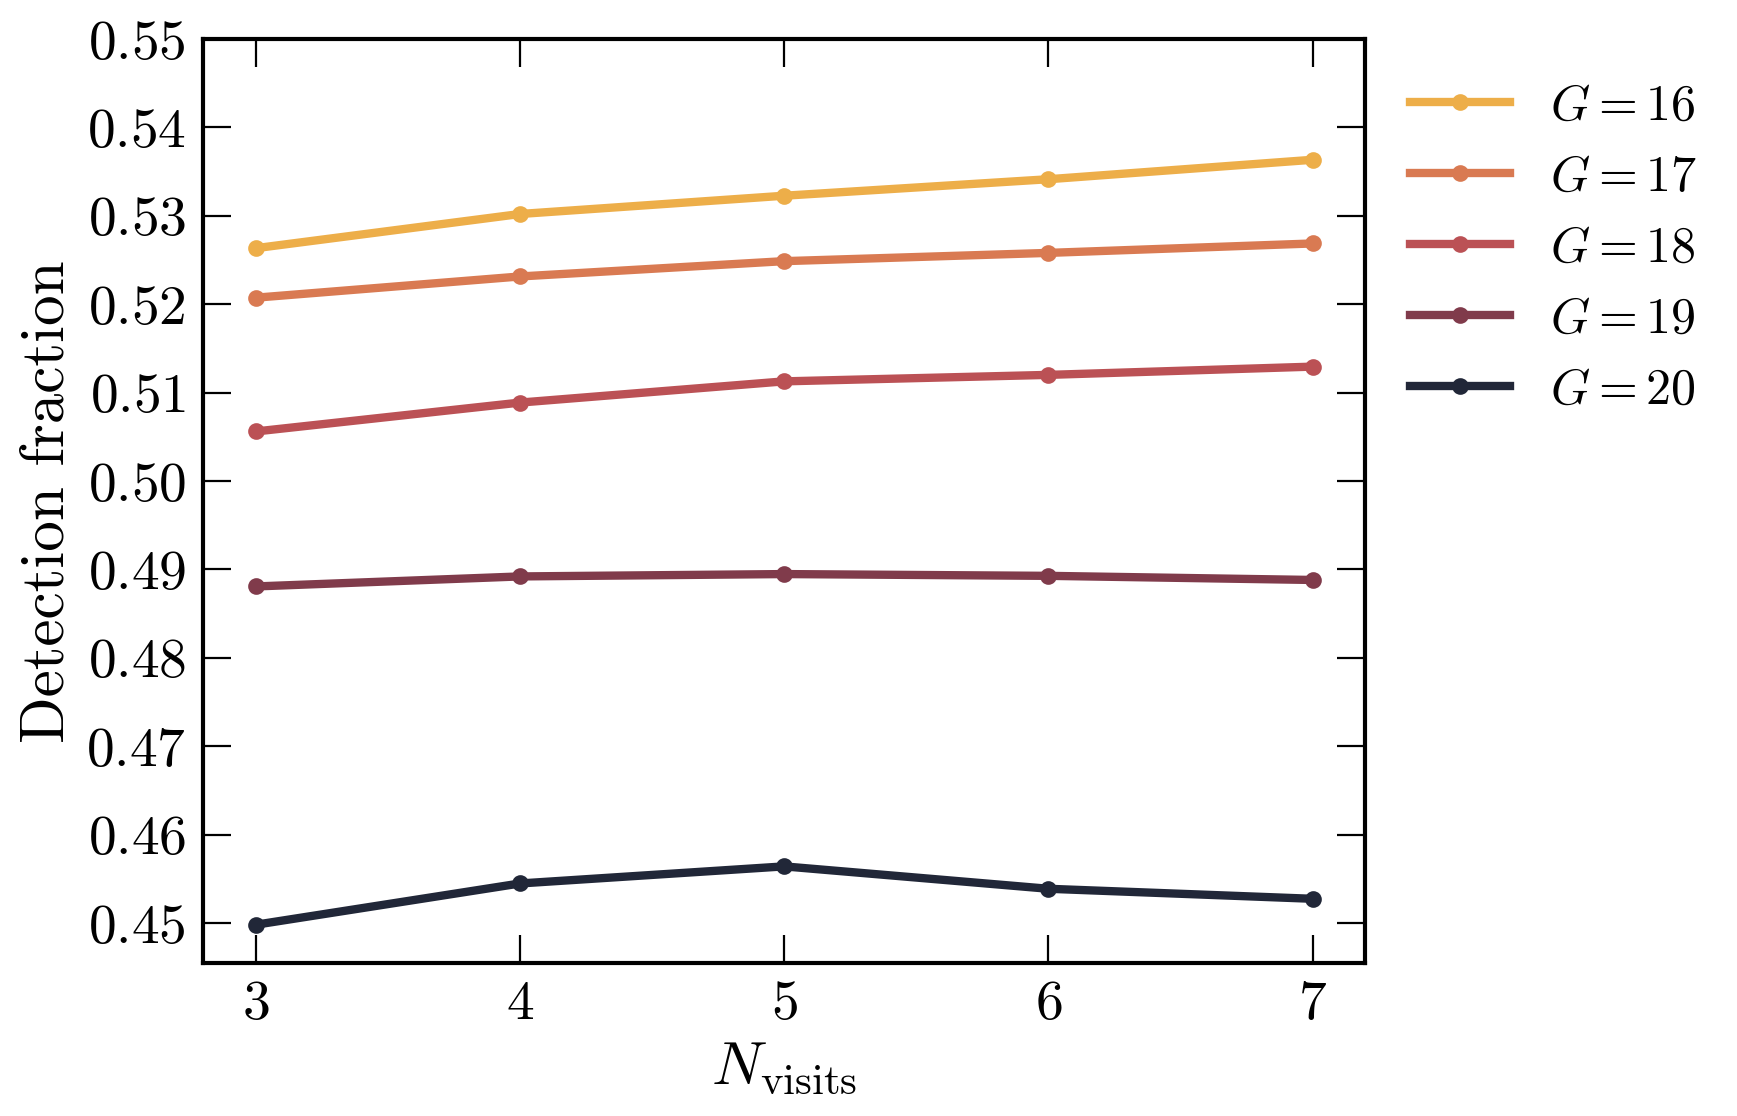

In [184]:
fig, axs = plt.subplots(1,1, figsize=[15/2,6])
plt.subplots_adjust(hspace=0.1)

cc = time_cmap(np.linspace(0, 1, len(Gmags_list)))

for k, G in enumerate(Gmags_list):
    ervs_this_G = ervs[k]
    detection_fractions_this_G = detection_fractions[k]
    axs.plot(nvisits_list, detection_fractions_this_G,marker='o',  label=r'$G=%i$'%G, c=cc[k])


    # axs[1].plot(nvisits_list, ervs_this_G, marker='o', label=r'$G=%i$'%G, c=cc[k])

# axs[0].set_yticks()
axs.set_ylabel('Detection fraction')
# axs[1].set_ylabel(r'$\sigma_{\rm RV}~\rm[km~s^{-1}]$')

# axs[0].set_ylim(0.485, 0.49)

# for ax in axs:
axs.set_xlabel(r'$N_{\rm visits}$')
# axs.set_xlim(2.5, max(nvisits_list)+0.5)
axs.set_xticks(nvisits_list)
axs.minorticks_off()
axs.set_yticks(np.arange(0.45, 0.55, 0.01))
# axs.set_xscale('log')
# axs.set_yscale('log')
    # ax.set_yscale('log')
    # ax.set_xscale('log')
    # ax.set_ylim(0,1)
axs.legend(loc='upper left', bbox_to_anchor=[1,1])